# AEMET - Zaragoza single-site radar reflectivity 

This notebook describes how to access and use the zarr-version of the radar reflectivity dataset for the Zaragoza radar (ZAR), derived from PPI radar products and converted into a CF/MLCAST-compliant Zarr archive. The dataset contains equivalent radar reflectivity factor fields in dBZ, stored on the original radar grid with 2D latitude/longitude coordinates, a 10-minute temporal resolution, and temporal coverage from 2020 to 2024.

The dataset has been generated with the code hosted on [https://github.com/mlcast-community/mlcast-dataset-ES-AEMET-reflectivity/tree/main](https://github.com/mlcast-community/mlcast-dataset-ES-AEMET-reflectivity/tree/main)

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import mlcast_datasets



In [2]:
cat = mlcast_datasets.open_catalog()
list(cat.precipitation)

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min',
 'es_aemet_ppi_zar_10_minutes',
 'es_aemet_sri_zar_10_minutes']

# AEMET - ZAR radar 10-min reflectivity

Mlcast catalog contains multiple datasets, hence to call specifically for AEMET Zaragoza radar data:

In [37]:
ds = cat.precipitation.es_aemet_ppi_zar_10_minutes.to_dask()
ds

<xarray.Dataset> Size: 241GB
Dimensions:        (time: 247771, y: 494, x: 493, missing_times: 15317)
Coordinates:
  * time           (time) datetime64[ns] 2MB 2020-01-01 ... 2024-12-31T23:50:00
  * y              (y) float64 4kB 4.377e+06 4.378e+06 ... 4.869e+06 4.87e+06
  * x              (x) float64 4kB 4.578e+05 4.588e+05 ... 9.49e+05 9.5e+05
    lat            (y, x) float32 974kB dask.array<chunksize=(494, 493), meta=np.ndarray>
    lon            (y, x) float32 974kB dask.array<chunksize=(494, 493), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[ns] 123kB 2020-01-08T05:30:00 ....
Data variables:
    dbz            (time, y, x) float32 241GB dask.array<chunksize=(1, 494, 493), meta=np.ndarray>
    spatial_ref    int32 4B ...
Attributes: (12/18)
    CDI:                               Climate Data Interface version 1.8.2 (...
    history:                           Converted from NetCDF radar files to Zarr
    Conventions:                       CF-1.10
    GDAL:                              GDAL 2.2.3, released 2017/11/20
    CDO:                               Climate Data Operators version 1.8.2 (...
    title:                             Radar test dataset converted to GeoZar...
    ...                                ...
    mlcast_created_with:               https://github.com/mlcast-community/ml...
    mlcast_dataset_version:            0.1.0
    mlcast_dataset_identifier:         ES-AEMET-radar_reflectivity-ppi_ZAR
    mlcast_dataset_identifier_format:  {country_code}-{entity}-{physical_vari...
    consistent_timestep_start:         2020-01-01T00:00
    base_frequencies:                  10min:2020-01-01T00:00/None

In [55]:
var_name = "dbz"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

print(data_crs)

PROJCRS["ETRS89 / UTM zone 30N",BASEGEOGCRS["ETRS89",ENSEMBLE["European Terrestrial Reference System 1989 ensemble",MEMBER["European Terrestrial Reference Frame 1989"],MEMBER["European Terrestrial Reference Frame 1990"],MEMBER["European Terrestrial Reference Frame 1991"],MEMBER["European Terrestrial Reference Frame 1992"],MEMBER["European Terrestrial Reference Frame 1993"],MEMBER["European Terrestrial Reference Frame 1994"],MEMBER["European Terrestrial Reference Frame 1996"],MEMBER["European Terrestrial Reference Frame 1997"],MEMBER["European Terrestrial Reference Frame 2000"],MEMBER["European Terrestrial Reference Frame 2005"],MEMBER["European Terrestrial Reference Frame 2014"],MEMBER["European Terrestrial Reference Frame 2020"],ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[0.1]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4258]],CONVERSION["UTM zone 30N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude o

In [56]:
da = ds[var_name].sel(time="2024-06-30").isel(time=0)

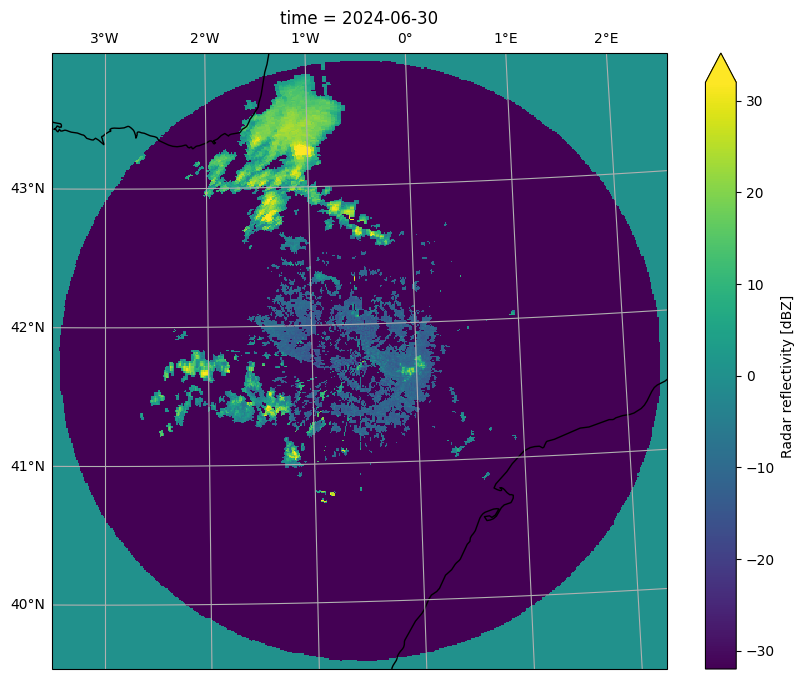

In [58]:
data_crs = ccrs.UTM(
    zone=30,
    southern_hemisphere=False,
)

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=data_crs)

da.plot(
    ax=ax,
    transform=data_crs,
    cmap="viridis",
    robust=True,
    add_colorbar=True,
)

ax.set_xlim(
    float(da.x.min()),
    float(da.x.max()),
)
 
ax.set_ylim(
    float(da.y.min()),
    float(da.y.max()),
)

ax.coastlines()
ax.gridlines(draw_labels=["top", "left"])

plt.show()

# AEMET - ZAR radar 10-min rainfall rate

Mlcast catalog contains multiple datasets, hence to call specifically for AEMET Zaragoza radar data:

In [65]:
ds = cat.precipitation.es_aemet_sri_zar_10_minutes.to_dask()
ds

KeyboardInterrupt: 

In [62]:
var_name = "rainfall_rate"

crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

print(data_crs)

PROJCRS["ETRS89 / UTM zone 30N",BASEGEOGCRS["ETRS89",ENSEMBLE["European Terrestrial Reference System 1989 ensemble",MEMBER["European Terrestrial Reference Frame 1989"],MEMBER["European Terrestrial Reference Frame 1990"],MEMBER["European Terrestrial Reference Frame 1991"],MEMBER["European Terrestrial Reference Frame 1992"],MEMBER["European Terrestrial Reference Frame 1993"],MEMBER["European Terrestrial Reference Frame 1994"],MEMBER["European Terrestrial Reference Frame 1996"],MEMBER["European Terrestrial Reference Frame 1997"],MEMBER["European Terrestrial Reference Frame 2000"],MEMBER["European Terrestrial Reference Frame 2005"],MEMBER["European Terrestrial Reference Frame 2014"],MEMBER["European Terrestrial Reference Frame 2020"],ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[0.1]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4258]],CONVERSION["UTM zone 30N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude o

In [63]:
da = ds[var_name].sel(time="2024-06-30").isel(time=0)

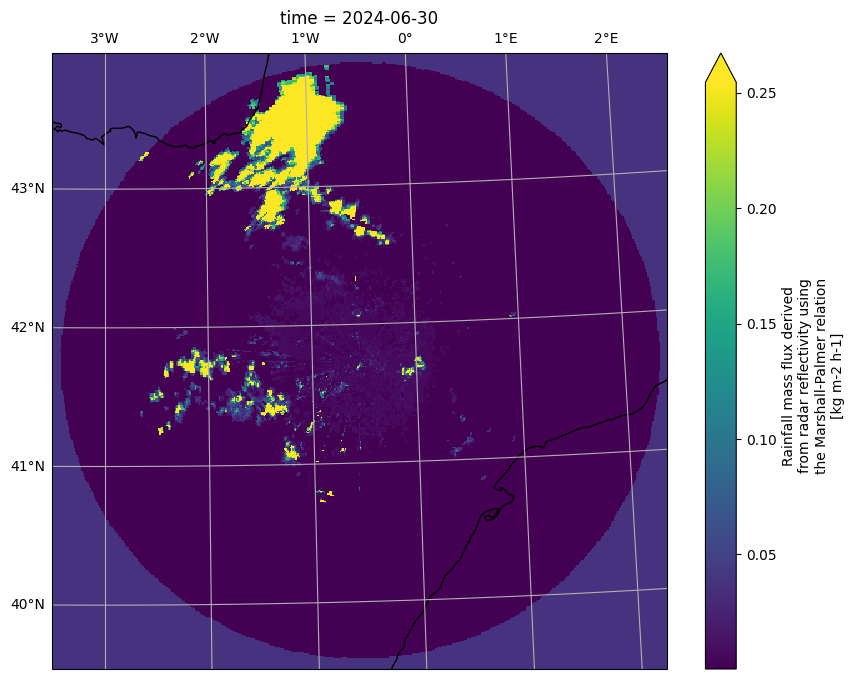

In [64]:
data_crs = ccrs.UTM(
    zone=30,
    southern_hemisphere=False,
)

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=data_crs)

da.plot(
    ax=ax,
    transform=data_crs,
    cmap="viridis",
    robust=True,
    add_colorbar=True,
)

ax.set_xlim(
    float(da.x.min()),
    float(da.x.max()),
)
 
ax.set_ylim(
    float(da.y.min()),
    float(da.y.max()),
)

ax.coastlines()
ax.gridlines(draw_labels=["top", "left"])

plt.show()

In [ ]:
# NOTE:
# Although the data are stored in ETRS89 / UTM zone 30N (EPSG:25830),
# using `ccrs.epsg(25830)` may cause Cartopy to clip part of the domain.
# This is related to the projection bounds inferred internally from the
# EPSG definition, rather than to an issue with the dataset coordinates.
#
# To avoid this clipping behaviour, the projection is defined explicitly
# as UTM zone 30N. For plotting purposes, this provides the expected
# projection geometry and correctly displays the full spatial domain.
data_crs = ccrs.UTM(
    zone=30,
    southern_hemisphere=False,
)